## Forward ODE Example, One Initial Condition

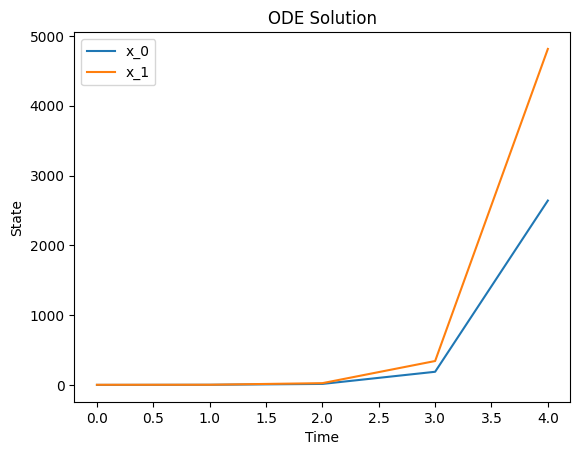

In [1]:

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

# Initial condition: (-1,1)
# Equation:
#   x_0' = -1*x_0 + 2*x_1
#   x_1' =  3*x_0 + 1*x_1
initial = np.asarray([-1, 1])
coeffs = np.asarray([[-1, 2], [3, 1]])
t_eval = np.arange(0, 4+1, 1)

def f(t, y):
    # Calculate dy/dt = Ay where A is coeffs matrix
    return coeffs @ y

solution = solve_ivp(f, [t_eval[0], t_eval[-1]], initial, t_eval=t_eval, method='RK45')
t_points = solution.t
y_points = solution.y.T

# Plot
plt.plot(t_points, y_points)
plt.legend(['x_0', 'x_1'])
plt.xlabel('Time')
plt.ylabel('State')
plt.title('ODE Solution')
plt.show()



## Forward ODE Example, Multiple Initial Conditions

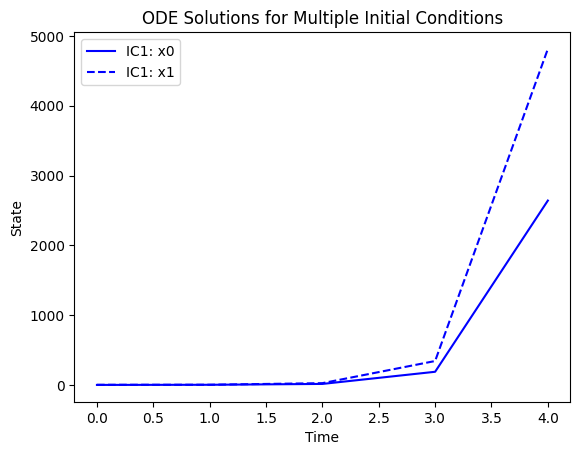

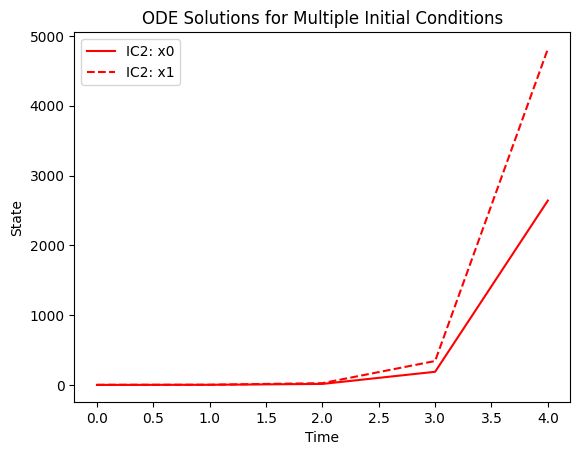

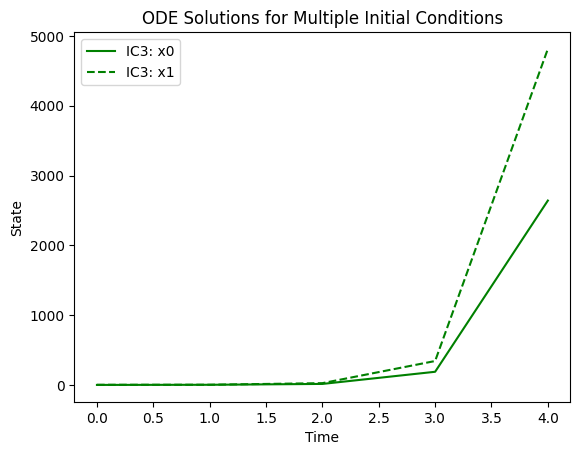

In [2]:


from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

# Initial conditions: (-1,1) and (-1,1)
# Equation:
#   x_0' = -1*x_0 + 2*x_1
#   x_1' =  3*x_0 + 1*x_1
initials = np.asarray([[-1, 1], [-1, 1], [-1, 1]])
coeffs = np.asarray([[-1, 2], [3, 1]])
t_eval = np.arange(0, 4+1, 1)

def f(t, y, n_eqs, n_vars):
    # Calculate dy/dt = Ay where A is coeffs matrix
    # y shape is (4,) containing [x0_0, x0_1, x1_0, x1_1]
    # Reshape to (2,2) to handle both initial conditions
    y = y.reshape(n_eqs, n_vars).T
    # Apply coeffs matrix to each initial condition
    dy = coeffs @ y
    dy = dy.T
    # Return flattened result
    return dy.flatten()

# Flatten initial conditions for solver
initial_flat = initials.flatten()

solution = solve_ivp(f, [t_eval[0], t_eval[-1]], initial_flat, t_eval=t_eval, method='RK45', args=(initials.shape[0], initials.shape[1]))
t_points = solution.t

# Reshape solution back to (time, 2 ICs, 2 vars)
y_points = solution.y.T.reshape(-1, initials.shape[0], initials.shape[1])

# Plot all solutions
colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
for i in range(y_points.shape[1]):
    plt.plot(t_points, y_points[:,i,0], f'{colors[i%len(colors)]}-', label=f'IC{i+1}: x0')
    plt.plot(t_points, y_points[:,i,1], f'{colors[i%len(colors)]}--', label=f'IC{i+1}: x1')
    plt.xlabel('Time')
    plt.ylabel('State')
    plt.title('ODE Solutions for Multiple Initial Conditions')
    plt.legend()
    plt.show()


## Forward ODE Example, Multiple Initial Conditions, use odeint


torch.Size([6])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 2])
torch.Size([3, 

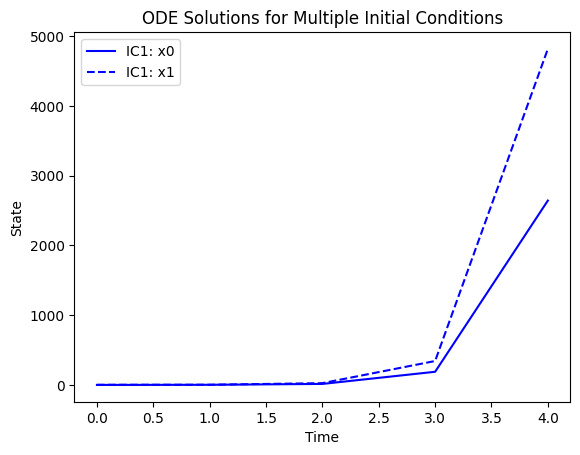

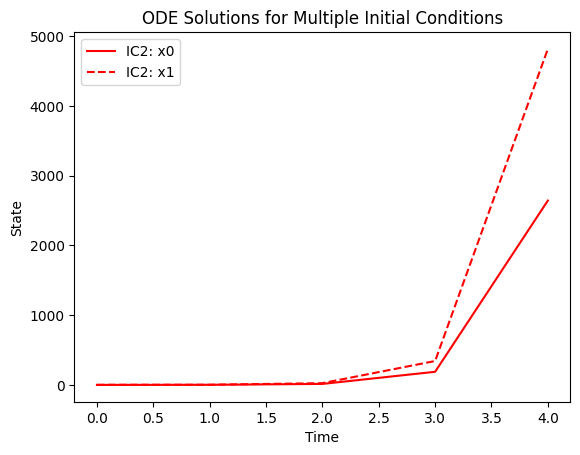

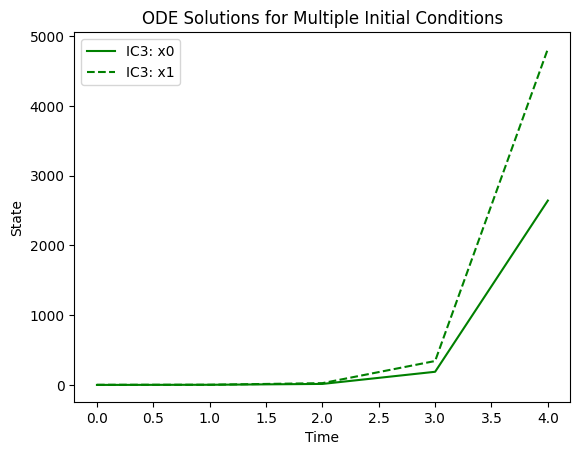

In [ ]:
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import numpy as np
import torch

# Initial conditions: (-1,1) and (-1,1)
# Equation:
#   x_0' = -1*x_0 + 2*x_1
#   x_1' =  3*x_0 + 1*x_1
initials = np.asarray([[-1, 1], [-1, 1], [-1, 1]])
coeffs = np.asarray([[-1, 2], [3, 1]])
t_eval = np.arange(0, 4+1, 1)

# Convert all to torch
initials = torch.from_numpy(initials).float()
coeffs = torch.from_numpy(coeffs).float()
t_eval = torch.from_numpy(t_eval).float()

n_eqs = initials.shape[0]
n_vars = initials.shape[1]

def f(t, y):
    # Calculate dy/dt = Ay where A is coeffs matrix
    # y shape is (4,) containing [x0_0, x0_1, x1_0, x1_1]
    # Reshape to (2,2) to handle both initial conditions
    y = y.reshape(n_eqs, n_vars).T
    # Apply coeffs matrix to each initial condition
    dy = coeffs @ y
    dy = dy.T
    # Return flattened result
    return dy.flatten()

# Flatten initial conditions for solver
initial_flat = initials.flatten()

# Solve using odeint
print(initial_flat.shape)
y_points = odeint(f, initial_flat, t_eval)

# Reshape solution back to (time, 2 ICs, 2 vars)
y_points = y_points.reshape(-1, initials.shape[0], initials.shape[1])

# Plot all solutions
colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
for i in range(y_points.shape[1]):
    plt.plot(t_eval, y_points[:,i,0], f'{colors[i%len(colors)]}-', label=f'IC{i+1}: x0')
    plt.plot(t_eval, y_points[:,i,1], f'{colors[i%len(colors)]}--', label=f'IC{i+1}: x1')
    plt.xlabel('Time')
    plt.ylabel('State')
    plt.title('ODE Solutions for Multiple Initial Conditions')
    plt.legend()
    plt.show()
